# Fractal with ray marching method 

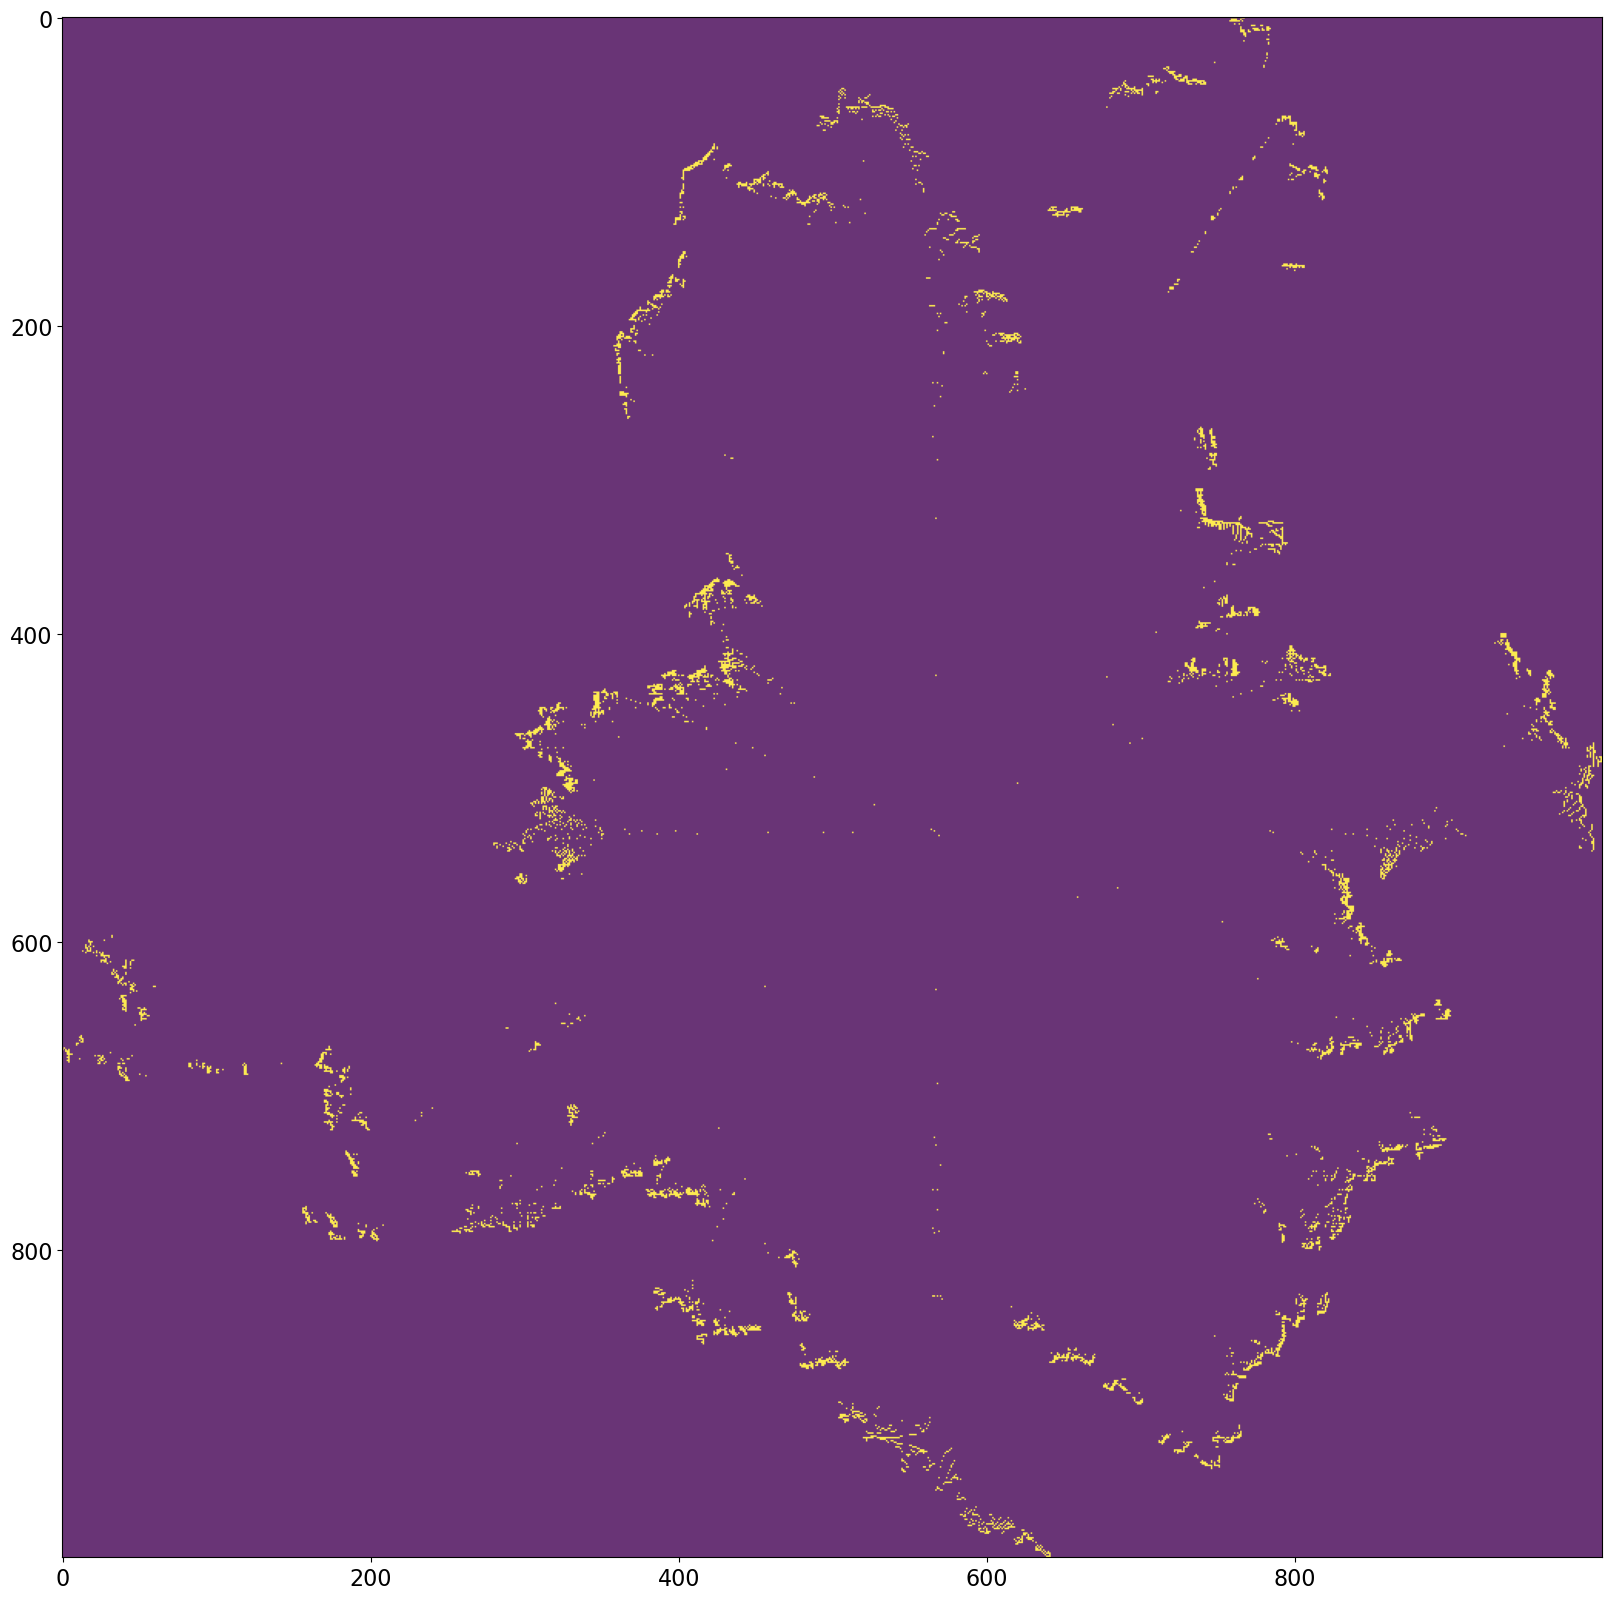

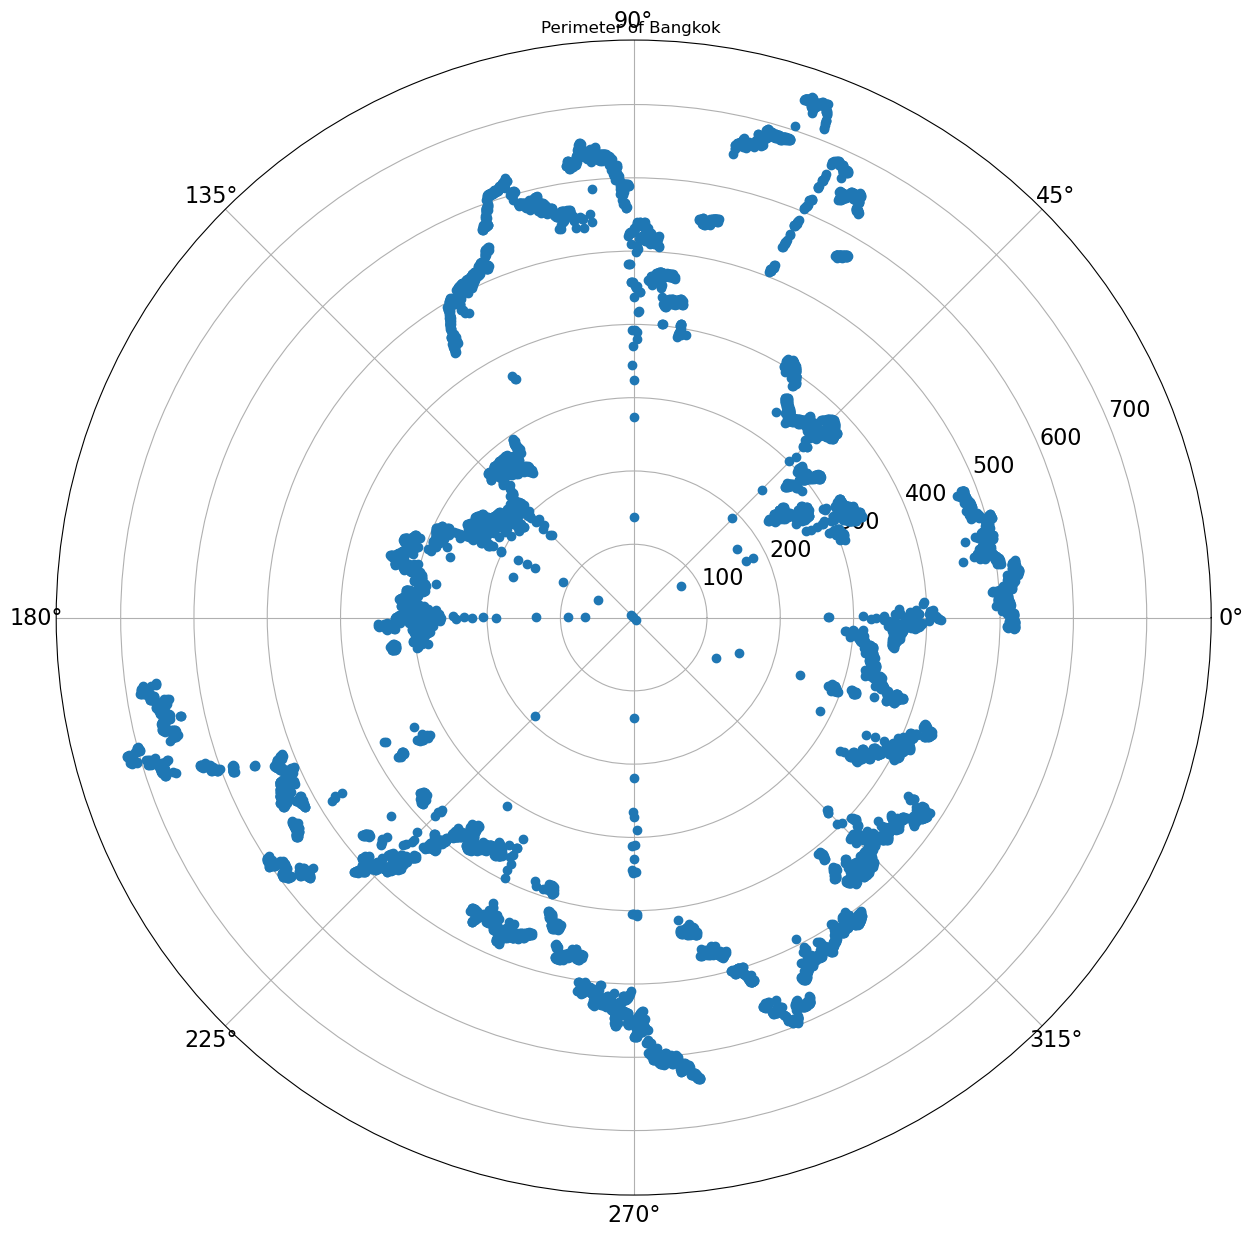

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import numpy as np
import porespy as ps

# load csv
city='Bangkok'
df = pd.read_csv(f"perimeter_fractal_{city}_10000.csv")

df_year=df[df['year']==1985]

rows=df_year['row'].values
cols=df_year['col'].values

angle=df_year['sector_angle_rad'].values
distance=df_year['distance_pixels'].values

row_min, row_max = rows.min(), rows.max()
col_min, col_max = cols.min(), cols.max()

rows_scaled = ((rows - row_min) / (row_max - row_min) * 999).astype(int)
cols_scaled = ((cols - col_min) / (col_max - col_min) * 999).astype(int)


# Create grid
grid = np.zeros((1000, 1000), dtype=np.uint8)

# Set perimeter pixels
grid[rows_scaled, cols_scaled] = 1


plt.figure(figsize=(20,20))
plt.imshow(grid,alpha=0.8)
plt.show()

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='polar')                
ax.plot(angle, distance,'o')
plt.title(f'Perimeter of {city} ')
ax.grid(True)
plt.show()




## plot of slope N vs epsi

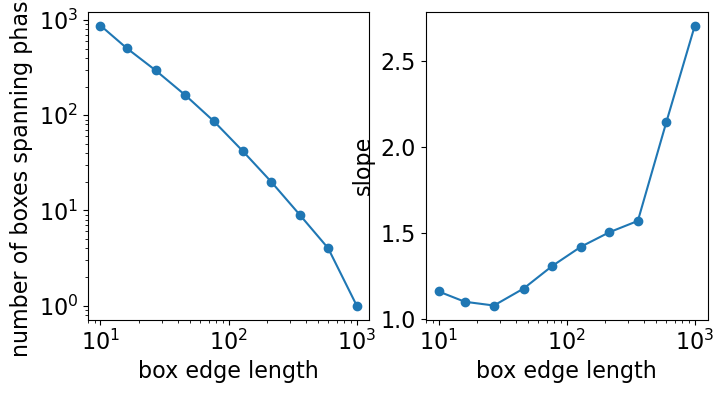

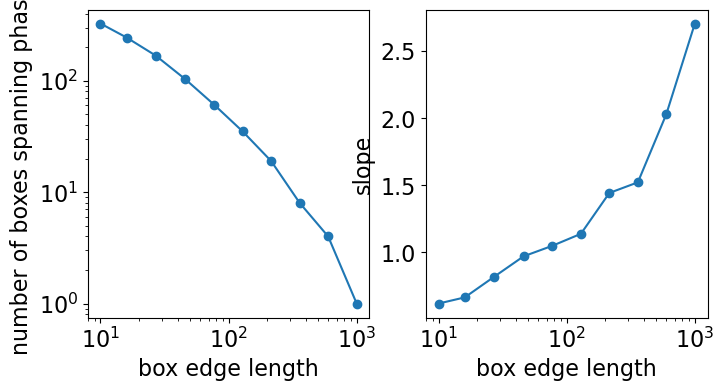

In [16]:
data=ps.metrics.boxcount(grid)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel("box edge length")
ax1.set_ylabel("number of boxes spanning phases")
ax2.set_xlabel("box edge length")
ax2.set_ylabel("slope")
ax2.set_xscale("log")
ax1.plot(data.size, data.count, "-o")
ax2.plot(data.size, data.slope, "-o")


df = pd.read_csv("perimeter_fractal_Bangkok_500.csv")

df_year=df[df['year']==1985]

rows=df_year['row'].values
cols=df_year['col'].values


row_min, row_max = rows.min(), rows.max()
col_min, col_max = cols.min(), cols.max()

rows_scaled = ((rows - row_min) / (row_max - row_min) * 999).astype(int)
cols_scaled = ((cols - col_min) / (col_max - col_min) * 999).astype(int)


# Create grid
grid = np.zeros((1000, 1000), dtype=np.uint8)

# Set perimeter pixels
grid[rows_scaled, cols_scaled] = 1




data=ps.metrics.boxcount(grid)





fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel("box edge length")
ax1.set_ylabel("number of boxes spanning phases")
ax2.set_xlabel("box edge length")
ax2.set_ylabel("slope")
ax2.set_xscale("log")
ax1.plot(data.size, data.count, "-o")
ax2.plot(data.size, data.slope, "-o")
plt.show()



In [33]:
data=pd.DataFrame({'City': ['Ningbo','Chengdu Deyang', 'Beijing','Changzhou','Bengalore','Kolkata','Paris','Bangkok','Cairo','Guatemala City','Johannesburg','London','Mexico City','Nairobi','Santiago','Sao Paulo','Tehran','Las Vegas','Atlanta'],
      'alpha':[0.56, 0.53, 0.54, 0.54, 0.55, 0.52, 0.52 ,0.53, 0.53, 0.52, 0.58, 0.54, 0.55, 0.56, 0.58, 0.51, 0.55, 0.55, 0.56],
      'beta': [0.44, 0.68, 0.41, 0.37, 0.83, 0.34, 0.56, 1.01, 0.37, 0.37, 0.07, 0.01, 0.04, 0.28, 0.62, 0.89, 0.10, 0.41, 0.04],
       '1/z': [0.58, 0.68, 0.58, 0.56, 0.72, 0.74, 0.76, 0.80, 0.54, 0.33, 0.27, 0.21, 0.25, 0.27, 0.74, 0.41, 0.54, 0.37, 0.52]})

cities= data['City']
betas=data['beta']

frac_arr=[]
frac_arr_1985=[]
frac_arr_2015=[]

# fit parameter : 
end_fit=8
year=1999

for city in cities:
    df = pd.read_csv(f"perimeter_fractal_{city}_500.csv")

    df_year=df[df['year']==year]

    rows=df_year['row'].values
    cols=df_year['col'].values


    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()

    rows_scaled = ((rows - row_min) / (row_max - row_min) * 999).astype(int)
    cols_scaled = ((cols - col_min) / (col_max - col_min) * 999).astype(int)


    # Create grid
    grid_1985 = np.zeros((1000, 1000), dtype=np.uint8)

    # Set perimeter pixels
    grid_1985[rows_scaled, cols_scaled] = 1
    
    # Apply Boxcount
    data_1985=ps.metrics.boxcount(grid_1985)

    p_1985=np.polyfit(np.log10(data_1985.size[0:end_fit]),np.log10(data_1985.count[0:end_fit]),1)
    frac_arr_1985.append(-p_1985[0])









Text(0, 0.5, '$\\beta$')

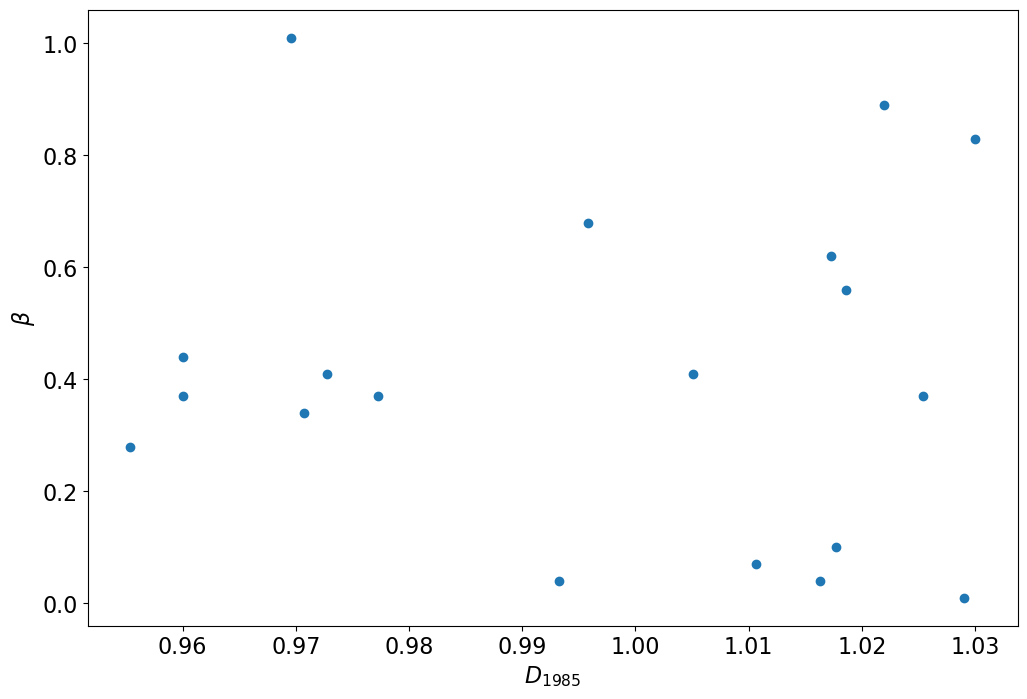

In [34]:
# plot the results

import matplotlib as mpl
mpl.rcParams['axes.labelsize']=16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

plt.figure(figsize=(12,8))
plt.scatter(np.array(frac_arr_1985),betas)
plt.xlabel(r'$D_{1985}$')
plt.ylabel(r'$\beta$')






In [35]:
frac_arr=[]
years=range(1985,2015,1)
for year in years:
    df = pd.read_csv(f"perimeter_fractal_Bangkok_500.csv")

    df_year=df[df['year']==year]

    rows=df_year['row'].values
    cols=df_year['col'].values


    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()

    rows_scaled = ((rows - row_min) / (row_max - row_min) * 999).astype(int)
    cols_scaled = ((cols - col_min) / (col_max - col_min) * 999).astype(int)


    # Create grid
    grid_1985 = np.zeros((1000, 1000), dtype=np.uint8)

    # Set perimeter pixels
    grid_1985[rows_scaled, cols_scaled] = 1
    
    # Apply Boxcount
    data_1985=ps.metrics.boxcount(grid_1985)

    p=np.polyfit(np.log10(data_1985.size[0:end_fit]),np.log10(data_1985.count[0:end_fit]),1)
    frac_arr.append(-p[0])

    

Text(0, 0.5, '$\\beta$')

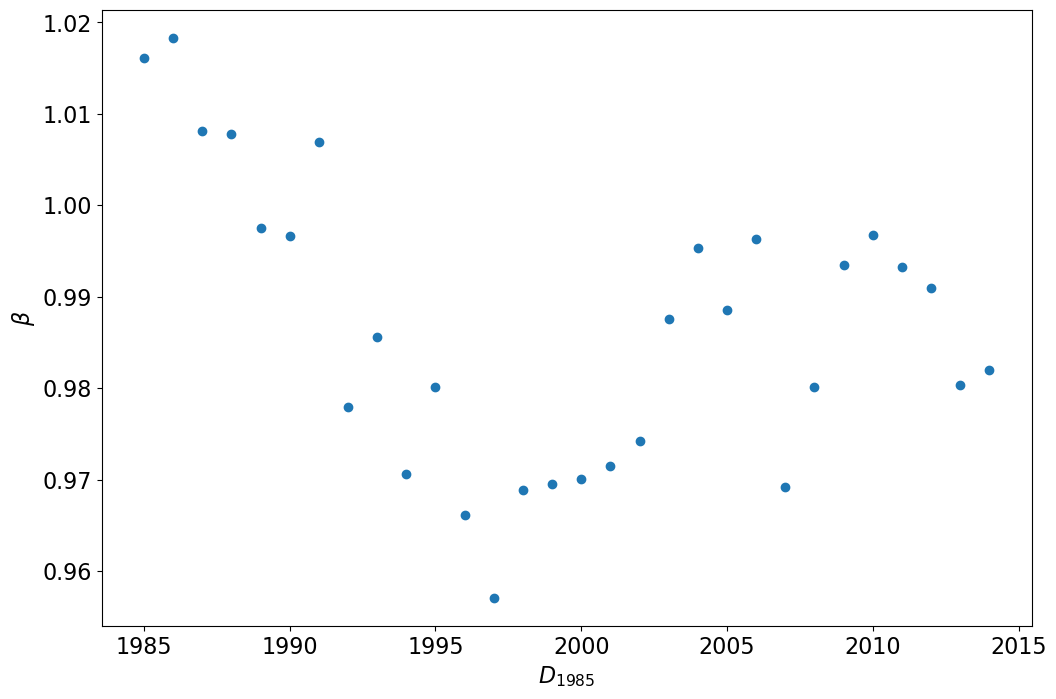

In [36]:
plt.figure(figsize=(12,8))
plt.scatter(years,np.array(frac_arr))
plt.xlabel(r'$D_{1985}$')
plt.ylabel(r'$\beta$')

# Convolution method 

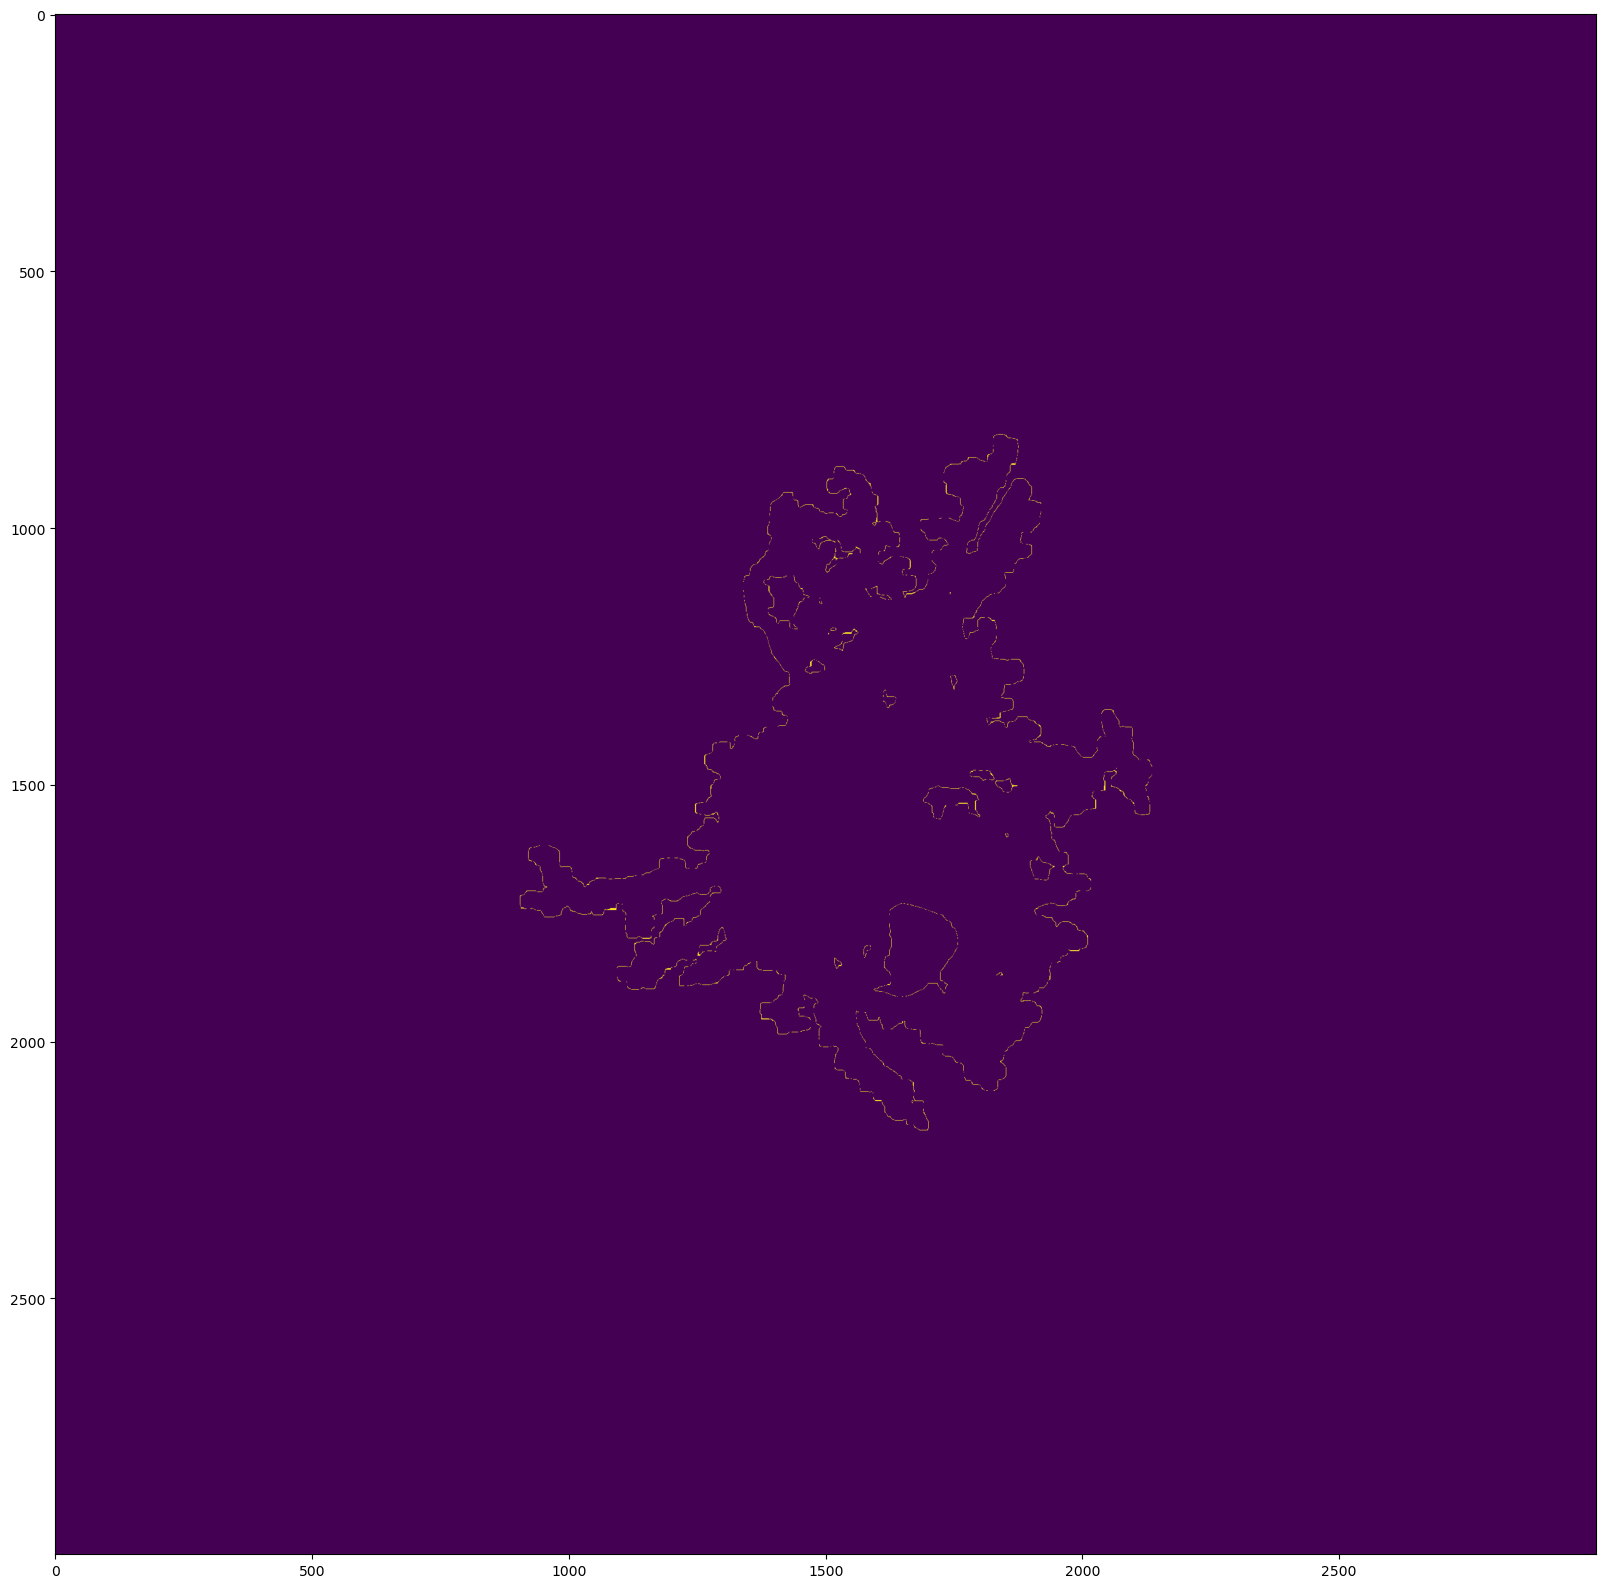

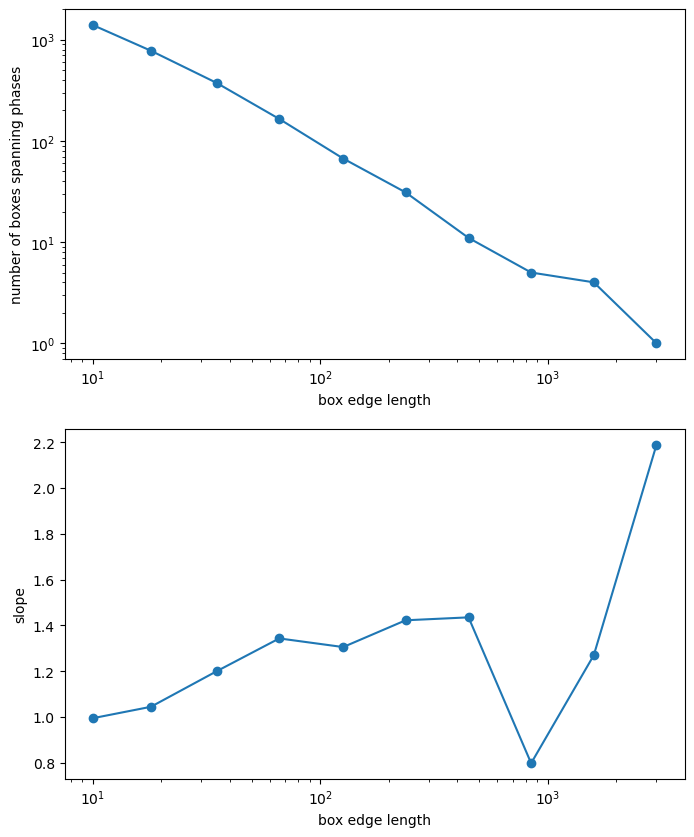

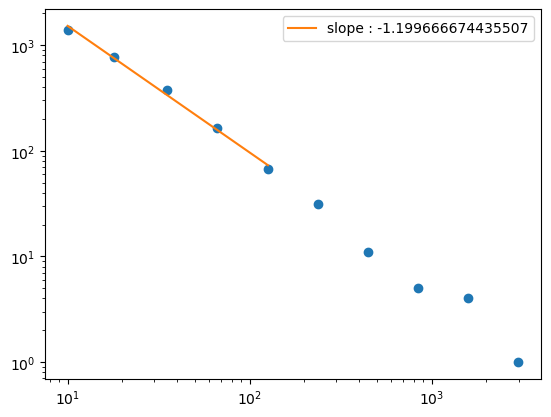

In [33]:
import pandas as pd
from scipy import ndimage as ndi
import numpy as np
import matplotlib.pyplot as plt
import porespy as ps


city='Bangkok'


df = pd.read_csv(f"mask_LCC_{city}_1985.csv")
mask=df

kernel = np.ones((20,20))
C      = ndi.convolve(mask, kernel, mode='constant', cval=0)

#print(C) # The C matrix contains the number of neighbors for each cell.

outer  = np.where( (C>=11) & (C<=15 ), 255, 0)


data=ps.metrics.boxcount(outer)

plt.figure(figsize=(20,20))
plt.imshow(outer)
plt.show

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel("box edge length")
ax1.set_ylabel("number of boxes spanning phases")
ax2.set_xlabel("box edge length")
ax2.set_ylabel("slope")
ax2.set_xscale("log")
ax1.plot(data.size, data.count, "-o")
ax2.plot(data.size, data.slope, "-o")
plt.show()



plt.figure()
plt.loglog(data.size,data.count,"o")
p=np.polyfit(np.log10(data.size[0:5]),np.log10(data.count[0:5]),1)
plt.loglog(data.size[0:5],10**(p[0]*np.log10(data.size[0:5])+p[1]),label=f'slope : {p[0]}')
plt.legend()



Text(0, 0.5, '$\\beta$')

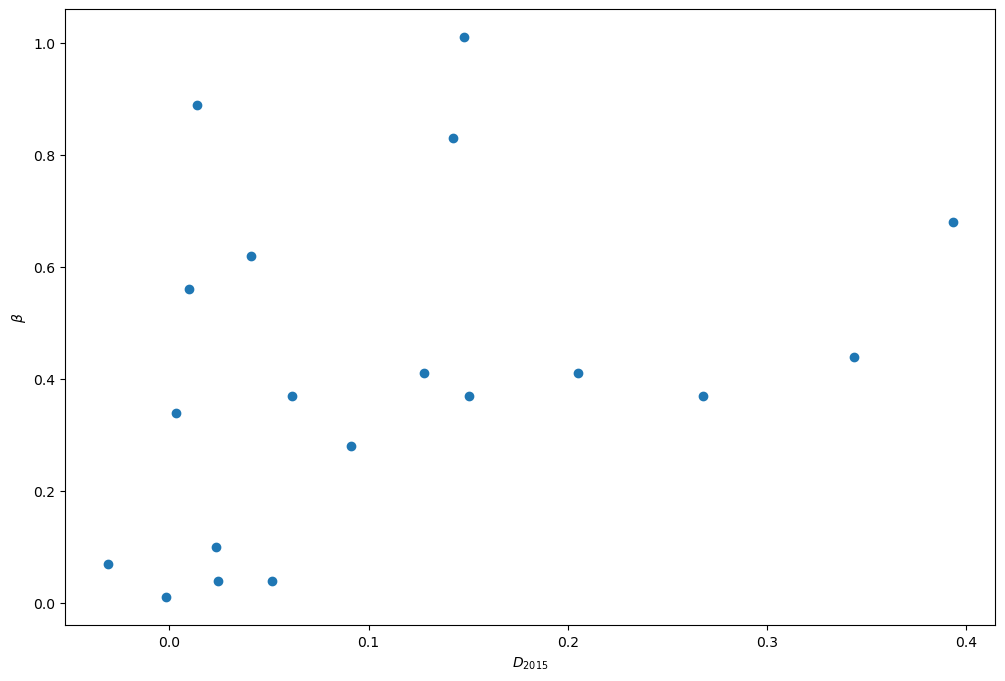

In [2]:
import pandas as pd
from scipy import ndimage as ndi
import numpy as np
import matplotlib.pyplot as plt
import porespy as ps


data=pd.DataFrame({'City': ['Ningbo','Chengdu Deyang', 'Beijing','Changzhou','Bengalore','Kolkata','Paris','Bangkok','Cairo','Guatemala City','Johannesburg','London','Mexico City','Nairobi','Santiago','Sao Paulo','Tehran','Las Vegas','Atlanta'],
      'alpha':[0.56, 0.53, 0.54, 0.54, 0.55, 0.52, 0.52 ,0.53, 0.53, 0.52, 0.58, 0.54, 0.55, 0.56, 0.58, 0.51, 0.55, 0.55, 0.56],
      'beta': [0.44, 0.68, 0.41, 0.37, 0.83, 0.34, 0.56, 1.01, 0.37, 0.37, 0.07, 0.01, 0.04, 0.28, 0.62, 0.89, 0.10, 0.41, 0.04],
       '1/z': [0.58, 0.68, 0.58, 0.56, 0.72, 0.74, 0.76, 0.80, 0.54, 0.33, 0.27, 0.21, 0.25, 0.27, 0.74, 0.41, 0.54, 0.37, 0.52]})

cities= data['City']
betas=data['beta']

p_arr_2015=[]
p_arr_1985=[]
for city in cities:
    
      df_2015 = pd.read_csv(f"mask_LCC_{city}_2015.csv")
      df_1985=  pd.read_csv(f"mask_LCC_{city}_1985.csv")
      mask_2015=df_2015
      mask_1985=df_1985

      kernel = np.ones((15,15))
      C_1985      = ndi.convolve(mask_1985, kernel, mode='constant', cval=0)

      #print(C) # The C matrix contains the number of neighbors for each cell.

      outer_1985  = np.where( (C_1985>=11) & (C_1985<=15 ), 255, 0)


      data_1985=ps.metrics.boxcount(outer_1985)

      p_1985=np.polyfit(np.log10(data_1985.size[0:8]),np.log10(data_1985.count[0:8]),1)
      p_arr_1985.append(-p_1985[0])




      kernel = np.ones((15,15))
      C_2015     = ndi.convolve(mask_2015, kernel, mode='constant', cval=0)

      #print(C) # The C matrix contains the number of neighbors for each cell.

      outer_2015  = np.where( (C_2015>=11) & (C_2015<=15 ), 255, 0)


      data_2015=ps.metrics.boxcount(outer_2015)

      p_2015=np.polyfit(np.log10(data_2015.size[0:8]),np.log10(data_2015.count[0:8]),1)
      p_arr_2015.append(-p_2015[0])


plt.figure(figsize=(12,8))
plt.scatter(np.array(p_arr_2015)-np.array(p_arr_1985),betas)
plt.xlabel(r'$D_{2015}$')
plt.ylabel(r'$\beta$')









Text(0.02, 0.98, 'Pearson r = 0.36 (p = 0.13)\nSpearman ρ = 0.21 (p = 0.38)')

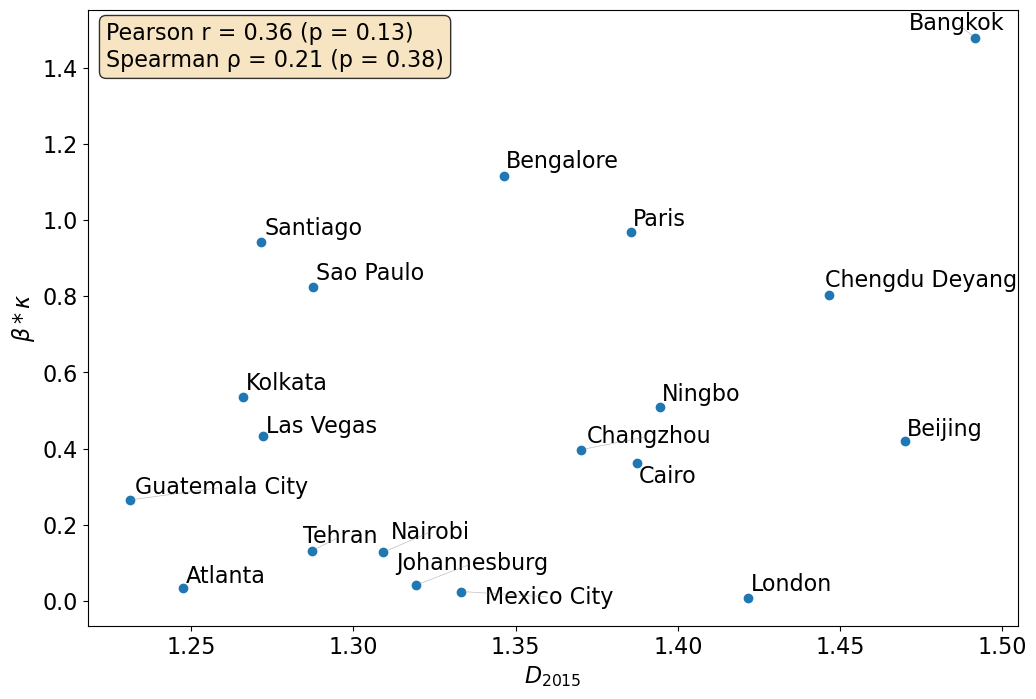

In [52]:
from adjustText import adjust_text
import matplotlib as mpl
from scipy import stats
mpl.rcParams['axes.labelsize']=16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['font.size']=16

def add_city_labels_with_adjusttext(ax, x_data, y_data, cities, fontsize=16):
    """Add city labels using adjustText library for automatic overlap avoidance"""
    texts = []
    for x, y, city in zip(x_data, y_data, cities):
        texts.append(ax.annotate(city, xy=(x, y), fontsize=fontsize))
    
    # Adjust text positions to minimize overlaps
    adjust_text(texts, 
                x=x_data, y=y_data,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5),
                ha='center', va='center',
                force_text=(0.3, 0.5),  # Force to push texts apart
                expand_text=(1.2, 1.5),  # Expand text bounding boxes
                expand_points=(1.2, 1.2))  # Expand point bounding boxes




kappa=pd.read_csv('kappa.csv')



data['kappa']=kappa['0']



x= np.array(p_arr_2015)
y= betas*kappa['0']


corr=np.corrcoef(x,y)
res=stats.spearmanr(x,y)
pearson_p = stats.pearsonr(x,y)[1]


plt.figure(figsize=(12,8))
plt.scatter(x,y)
# Add city labels
add_city_labels(plt.gca(), x,y, cities,fontsize=16)
plt.xlabel(r'$D_{2015}$')
plt.ylabel(r'$\beta* \kappa$')

# Add correlation statistics as text box
textstr = f'Pearson r = {corr[0,1]:.2f} (p = {pearson_p:.2f})\n' + \
          f'Spearman ρ = {res.correlation:.2f} (p = {res.pvalue:.2f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=16,
        verticalalignment='top', bbox=props)


